
# Fraud Detection Analysis for CMP7005 PRAC1
**Name:** Fathima Aabidha Rifky  
**Cardiff Met ID:** st20357374  
**ICBT ID:** CL-MCSDS-CMU-10-04  



In [88]:
import warnings, joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

for folder in ["figures", "tables", "logs", "models", "reports"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("Output folders created successfully.")

Output folders created successfully.


In [89]:

def find_file(patterns):
    search_roots = [Path("."), Path("/mnt/data")]
    matches = []
    for root in search_roots:
        for pattern in patterns:
            matches.extend(root.glob(pattern))
    matches = [m for m in matches if m.is_file()]
    if not matches:
        raise FileNotFoundError(f"No file found for patterns: {patterns}")
    matches = sorted(matches, key=lambda p: (len(str(p)), str(p)))
    return matches[0]

file1 = find_file(["*Credit*Sept_1*.csv", "*Credir*Sept_1*.csv"])
file2 = find_file(["*Credit*Sept_2*.csv", "*Credir*Sept_2*.csv"])

print("Dataset 1:", file1)
print("Dataset 2:", file2)


Dataset 1: Credit_Card_Dataset_2025_Sept_1.csv
Dataset 2: Credit_Card_Dataset_2025_Sept_2.csv


In [90]:
data_1 = pd.read_csv(file1)
data_2 = pd.read_csv(file2)

print("Dataset 1 shape:", data_1.shape)
print("Dataset 2 shape:", data_2.shape)
print("\nDataset 1 columns:", list(data_1.columns))
print("\nDataset 2 columns:", list(data_2.columns))

# Validate that the merge is one-to-one on the primary key
data_raw = pd.merge(
    data_1,
    data_2,
    left_on="ID",
    right_on="User",
    how="outer",
    validate="one_to_one"
)

print("\nRaw merged dataset shape:", data_raw.shape)

# Remove the redundant merge key and CSV index artifact from the analytical dataset
data = data_raw.drop(columns=[c for c in ["User", "Unnamed: 0"] if c in data_raw.columns]).copy()

print("Analytical dataset shape after removing redundant/non-analytical columns:", data.shape)
display(data.head())

merge_quality_summary = pd.DataFrame({
    "Check": [
        "Dataset 1 rows",
        "Dataset 2 rows",
        "Raw merged rows",
        "Raw merged columns",
        "Analytical dataset rows",
        "Analytical dataset columns",
        "Rows with missing ID after merge"
    ],
    "Value": [
        data_1.shape[0],
        data_2.shape[0],
        data_raw.shape[0],
        data_raw.shape[1],
        data.shape[0],
        data.shape[1],
        int(data["ID"].isna().sum())
    ]
})
display(merge_quality_summary)
merge_quality_summary.to_csv("tables/merge_quality_summary.csv", index=False)

with open("logs/data_loading_and_merging_log.txt", "w") as f:
    f.write(f"Dataset 1 path: {file1}\n")
    f.write(f"Dataset 2 path: {file2}\n")
    f.write(f"Dataset 1 shape: {data_1.shape}\n")
    f.write(f"Dataset 2 shape: {data_2.shape}\n")
    f.write(f"Raw merged shape: {data_raw.shape}\n")
    f.write(f"Analytical dataset shape: {data.shape}\n")
    f.write("Merge validation: one_to_one\n")

Dataset 1 shape: (25134, 17)
Dataset 2 shape: (25134, 4)

Dataset 1 columns: ['Unnamed: 0', 'ID', 'GENDER', 'CAR', 'REALITY', 'NO_OF_CHILD', 'FAMILY_TYPE', 'HOUSE_TYPE', 'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'TARGET']

Dataset 2 columns: ['INCOME', 'INCOME_TYPE', 'User', 'EDUCATION_TYPE']

Raw merged dataset shape: (25134, 21)
Analytical dataset shape after removing redundant/non-analytical columns: (25134, 19)


,ID,GENDER,CAR,REALITY,NO_OF_CHILD,FAMILY_TYPE,HOUSE_TYPE,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET,INCOME,INCOME_TYPE,EDUCATION_TYPE
0,5008806,M,Y,Y,0,Married,House / apartment,1,0,0,0,2.0,29,59,3.0,0,112500.0,Working,Secondary / secondary special
1,5008808,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,4,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
2,5008809,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
3,5008810,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special
4,5008811,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,38,52,8.0,0,270000.0,Commercial associate,Secondary / secondary special


,Check,Value
0,Dataset 1 rows,25134
1,Dataset 2 rows,25134
2,Raw merged rows,25134
3,Raw merged columns,21
4,Analytical dataset rows,25134
5,Analytical dataset columns,19
6,Rows with missing ID after merge,0


**Task 1 merge interpretation**

The two source files were merged using the shared identifiers **`ID`** and **`User`**, because these fields represent the common customer-level key across the two datasets. The merge was validated as **one-to-one**, which helps confirm that each record from one source matches at most one record from the other. After merging, redundant columns such as the duplicate key field and index-like CSV artefacts were removed so that the final working dataset matched the expected analytical structure more closely. The cleaned analytical dataset contains **25,134 records and 19 analytical features, including the binary fraud target**.

## Task 2A – Data understanding

In [91]:

dataset_shape = pd.DataFrame({"Metric": ["Rows", "Columns"], "Value": [data.shape[0], data.shape[1]]})
column_audit = pd.DataFrame({
    "Column": data.columns,
    "Data_Type": data.dtypes.astype(str).values,
    "Missing_Values": data.isnull().sum().values,
    "Missing_Percentage": (data.isnull().sum().values / len(data) * 100).round(3),
    "Unique_Values": [data[col].nunique(dropna=False) for col in data.columns]
}).sort_values(by=["Missing_Values", "Unique_Values"], ascending=[False, False])

dataset_shape.to_csv("tables/dataset_shape_summary.csv", index=False)
column_audit.to_csv("tables/column_audit_summary.csv", index=False)

display(dataset_shape)
display(column_audit)


,Metric,Value
0,Rows,25134
1,Columns,19


,Column,Data_Type,Missing_Values,Missing_Percentage,Unique_Values
17,INCOME_TYPE,object,12,0.048,6
14,YEARS_EMPLOYED,float64,9,0.036,44
11,FAMILY SIZE,float64,1,0.004,11
0,ID,int64,0,0.000,25134
16,INCOME,float64,0,0.000,195
12,BEGIN_MONTH,int64,0,0.000,61
13,AGE,int64,0,0.000,50
4,NO_OF_CHILD,int64,0,0.000,9
6,HOUSE_TYPE,object,0,0.000,6
5,FAMILY_TYPE,object,0,0.000,5


**Data-type interpretation**

The dataset contains a mix of **numerical** and **categorical** variables, which makes both encoding and scaling decisions important for a fair model comparison. This mixed data structure supports the use of pipeline-based preprocessing later in Task 3, because different variable types require different treatment.

In [93]:

duplicate_full_rows = int(data.duplicated().sum())
duplicate_id_rows = int(data["ID"].duplicated().sum()) if "ID" in data.columns else np.nan

duplicate_summary = pd.DataFrame({"Metric": ["Duplicate full rows", "Duplicate ID values"], "Value": [duplicate_full_rows, duplicate_id_rows]})
duplicate_summary.to_csv("tables/duplicate_summary.csv", index=False)
display(duplicate_summary)

if duplicate_full_rows > 0:
    data = data.drop_duplicates().copy()

print("Shape after duplicate handling:", data.shape)


,Metric,Value
0,Duplicate full rows,0
1,Duplicate ID values,0


Shape after duplicate handling: (25134, 19)


,Column,Missing_Count,Missing_Percentage
17,INCOME_TYPE,12,0.048
14,YEARS_EMPLOYED,9,0.036
11,FAMILY SIZE,1,0.004
2,CAR,0,0.000
1,GENDER,0,0.000
0,ID,0,0.000
3,REALITY,0,0.000
7,FLAG_MOBIL,0,0.000
4,NO_OF_CHILD,0,0.000
5,FAMILY_TYPE,0,0.000


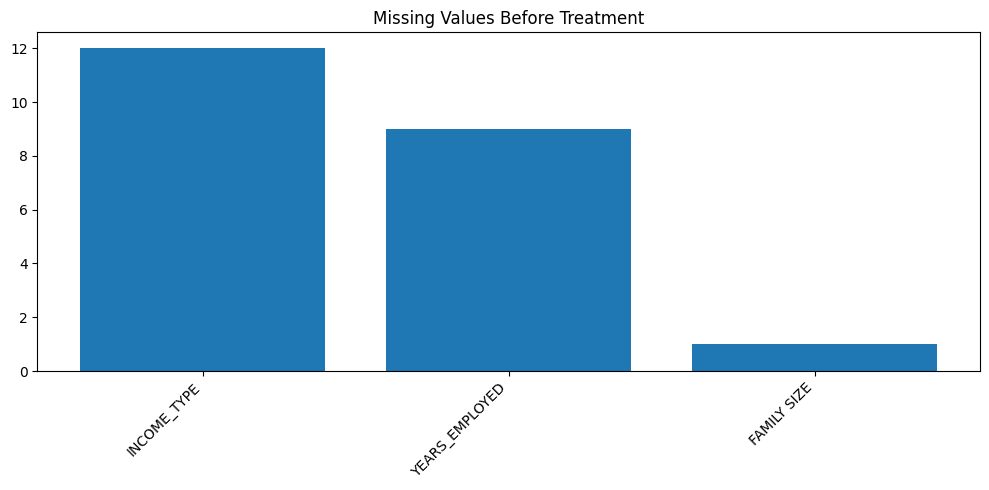

In [94]:

missing_summary_before = pd.DataFrame({"Column": data.columns, "Missing_Count": data.isnull().sum().values})
missing_summary_before["Missing_Percentage"] = (missing_summary_before["Missing_Count"] / len(data) * 100).round(3)
missing_summary_before = missing_summary_before.sort_values(by="Missing_Count", ascending=False)

missing_summary_before.to_csv("tables/missing_summary_before_treatment.csv", index=False)
display(missing_summary_before)

missing_nonzero = missing_summary_before[missing_summary_before["Missing_Count"] > 0]
if len(missing_nonzero) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(missing_nonzero["Column"], missing_nonzero["Missing_Count"])
    plt.title("Missing Values Before Treatment")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("figures/missing_values_before_treatment.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No missing values detected before treatment.")


In [95]:
task2a_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Numerical variables",
        "Categorical variables",
        "Fraud percentage",
        "Total missing values",
        "Duplicate full rows"
    ],
    "Value": [
        data.shape[0],
        data.shape[1],
        int(data.select_dtypes(include=[np.number]).shape[1]),
        int(data.select_dtypes(exclude=[np.number]).shape[1]),
        round(data["TARGET"].mean() * 100, 3) if "TARGET" in data.columns else np.nan,
        int(data.isnull().sum().sum()),
        duplicate_full_rows
    ]
})
display(task2a_summary)
task2a_summary.to_csv("tables/task2a_summary_table.csv", index=False)

,Metric,Value
0,Rows,25134.000
1,Columns,19.000
2,Numerical variables,12.000
3,Categorical variables,7.000
4,Fraud percentage,1.679
5,Total missing values,22.000
6,Duplicate full rows,0.000


**Missing-value interpretation**

Missing values occur in both **numerical** and **categorical** variables, so separate preprocessing strategies are needed rather than a single global replacement rule. This also supports the use of sklearn pipelines during modelling, because the train, validation and test sets can then be handled consistently without leakage.

## Task 2B – Preprocessing

In [97]:
def add_engineered_features(df):
    df = df.copy()

    if {"INCOME", "FAMILY SIZE"}.issubset(df.columns):
        income = pd.to_numeric(df["INCOME"], errors="coerce")
        family_size = pd.to_numeric(df["FAMILY SIZE"], errors="coerce").replace(0, np.nan)
        df["INCOME_PER_FAMILY_MEMBER"] = income / family_size

    contact_cols = [col for col in ["PHONE", "WORK_PHONE", "E_MAIL"] if col in df.columns]
    if contact_cols:
        contact_data = df[contact_cols].apply(pd.to_numeric, errors="coerce").fillna(0)
        df["HAS_CONTACT_INFO"] = (contact_data > 0).sum(axis=1)

    if "FAMILY SIZE" in df.columns:
        family_size_raw = pd.to_numeric(df["FAMILY SIZE"], errors="coerce")
        df["IS_LARGE_FAMILY"] = (family_size_raw >= 4).astype(int)

    return df

In [98]:
data_clean = data.copy()

numeric_columns = data_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = data_clean.select_dtypes(exclude=[np.number]).columns.tolist()

for col in numeric_columns:
    data_clean[col] = data_clean[col].fillna(data_clean[col].median())

for col in categorical_columns:
    mode_value = data_clean[col].mode(dropna=True)
    fill_value = mode_value.iloc[0] if len(mode_value) > 0 else "Unknown"
    data_clean[col] = data_clean[col].fillna(fill_value)

data_clean = add_engineered_features(data_clean)

engineered_feature_cols = [col for col in ["INCOME_PER_FAMILY_MEMBER", "HAS_CONTACT_INFO", "IS_LARGE_FAMILY"] if col in data_clean.columns]
engineered_feature_summary = pd.DataFrame({
    "Feature": engineered_feature_cols,
    "Missing_Values": [int(data_clean[col].isnull().sum()) for col in engineered_feature_cols],
    "Mean": [round(pd.to_numeric(data_clean[col], errors="coerce").mean(), 4) for col in engineered_feature_cols],
    "Min": [round(pd.to_numeric(data_clean[col], errors="coerce").min(), 4) for col in engineered_feature_cols],
    "Max": [round(pd.to_numeric(data_clean[col], errors="coerce").max(), 4) for col in engineered_feature_cols]
})

missing_summary_after = pd.DataFrame({"Column": data_clean.columns, "Missing_Count": data_clean.isnull().sum().values})
missing_summary_after["Missing_Percentage"] = (missing_summary_after["Missing_Count"] / len(data_clean) * 100).round(3)
missing_summary_after.to_csv("tables/missing_summary_after_treatment.csv", index=False)
engineered_feature_summary.to_csv("tables/engineered_feature_summary.csv", index=False)

display(missing_summary_after.sort_values(by="Missing_Count", ascending=False).head(20))
display(engineered_feature_summary)

,Column,Missing_Count,Missing_Percentage
0,ID,0,0.0
1,GENDER,0,0.0
2,CAR,0,0.0
3,REALITY,0,0.0
4,NO_OF_CHILD,0,0.0
5,FAMILY_TYPE,0,0.0
6,HOUSE_TYPE,0,0.0
7,FLAG_MOBIL,0,0.0
8,WORK_PHONE,0,0.0
9,PHONE,0,0.0


,Feature,Missing_Values,Mean,Min,Max
0,INCOME_PER_FAMILY_MEMBER,0,101962.1777,5625.0,900000.0
1,HAS_CONTACT_INFO,0,0.6673,0.0,3.0
2,IS_LARGE_FAMILY,0,0.1177,0.0,1.0


**Feature engineering note**

Feature engineering was used to capture household burden and contactability more directly than the raw fields alone. In particular, **income per family member** may reflect financial pressure more meaningfully than income alone, **HAS_CONTACT_INFO** summarises how many contact channels are available for a customer, and **IS_LARGE_FAMILY** adds a simple household-size flag that may help the model separate different profile types. These engineered features were intentionally kept simple and interpretable so they could strengthen the modelling process without reducing clarity.

**Outlier-treatment justification**

Outlier treatment was applied only to **continuous variables** where extreme values could distort descriptive summaries and visualisations. Count-based variables such as **number of children** and **family size** were not capped, because these are discrete household characteristics and arbitrary capping could reduce interpretability or create unrealistic values.

In [99]:
# For EDA, outlier treatment is applied only to continuous variables.
# Count variables such as NO_OF_CHILD and FAMILY SIZE are not capped
# because fractional values would be unrealistic.
candidate_numeric_cols = [col for col in ["AGE", "YEARS_EMPLOYED", "INCOME"] if col in data_clean.columns]

data_capped = data_clean.copy()
outlier_records = []

for col in candidate_numeric_cols:
    q1 = data_capped[col].quantile(0.25)
    q3 = data_capped[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = int(((data_capped[col] < lower_bound) | (data_capped[col] > upper_bound)).sum())
    outlier_records.append({
        "Column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count_Before_Capping": outlier_count,
        "Outlier_Percentage_Before_Capping": round(outlier_count / len(data_capped) * 100, 3)
    })
    data_capped[col] = data_capped[col].clip(lower=lower_bound, upper=upper_bound)

outlier_summary = pd.DataFrame(outlier_records)
outlier_summary.to_csv("tables/outlier_summary.csv", index=False)
display(outlier_summary)

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count_Before_Capping,Outlier_Percentage_Before_Capping
0,AGE,33.0,48.0,15.0,10.5,70.5,5,0.020
1,YEARS_EMPLOYED,3.0,10.0,7.0,-7.5,20.5,1247,4.961
2,INCOME,135000.0,225000.0,90000.0,0.0,360000.0,1180,4.695


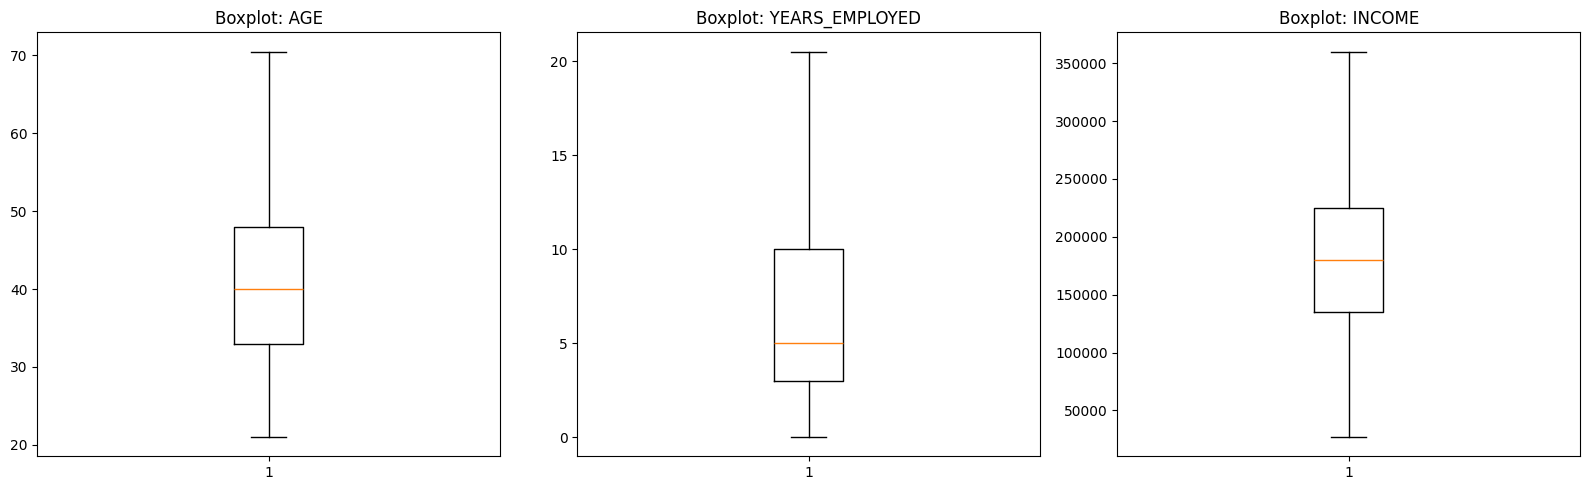

In [100]:
ncols = 3
nrows = int(np.ceil(len(candidate_numeric_cols) / ncols))

plt.figure(figsize=(16, 5 * nrows))
for i, col in enumerate(candidate_numeric_cols, 1):
    plt.subplot(nrows, ncols, i)
    plt.boxplot(data_capped[col].dropna(), vert=True)
    plt.title(f"Boxplot: {col}")

plt.tight_layout()
plt.savefig("figures/boxplots_after_outlier_capping.png", dpi=300, bbox_inches="tight")
plt.show()

## Task 2C – Statistical analysis and visualisation

In [101]:
stats_cols_to_drop = ["ID", "FLAG_MOBIL", "TARGET"]
numerical_stats = data_capped.drop(
    columns=[c for c in stats_cols_to_drop if c in data_capped.columns],
    errors="ignore"
).describe(include=[np.number]).T

numerical_stats.to_csv("tables/numerical_statistics.csv")
display(numerical_stats)

categorical_summary = []
for col in data_capped.select_dtypes(exclude=[np.number]).columns:
    vc = data_capped[col].value_counts(dropna=False)
    categorical_summary.append({
        "Column": col,
        "Most_Frequent_Value": vc.index[0] if len(vc) > 0 else np.nan,
        "Frequency": vc.iloc[0] if len(vc) > 0 else np.nan
    })

categorical_summary_df = pd.DataFrame(categorical_summary)
categorical_summary_df.to_csv("tables/categorical_summary.csv", index=False)
display(categorical_summary_df)

,count,mean,std,min,25%,50%,75%,max
NO_OF_CHILD,25134.0,0.512334,0.787785,0.0,0.0,0.0,1.0,19.0
WORK_PHONE,25134.0,0.273812,0.445923,0.0,0.0,0.0,1.0,1.0
PHONE,25134.0,0.292791,0.455052,0.0,0.0,0.0,1.0,1.0
E_MAIL,25134.0,0.100660,0.300885,0.0,0.0,0.0,0.0,1.0
FAMILY SIZE,25134.0,2.294064,0.947590,1.0,2.0,2.0,3.0,20.0
BEGIN_MONTH,25134.0,26.120594,16.439658,0.0,12.0,24.0,39.0,60.0
AGE,25134.0,40.542353,9.568012,21.0,33.0,40.0,48.0,70.5
YEARS_EMPLOYED,25134.0,6.910977,5.507234,0.0,3.0,5.0,10.0,20.5
INCOME,25134.0,188026.457209,79077.120877,27000.0,135000.0,180000.0,225000.0,360000.0
INCOME_PER_FAMILY_MEMBER,25134.0,101962.177662,75493.122045,5625.0,54000.0,78750.0,126000.0,900000.0


,Column,Most_Frequent_Value,Frequency
0,GENDER,F,15630
1,CAR,N,14618
2,REALITY,Y,16461
3,FAMILY_TYPE,Married,17509
4,HOUSE_TYPE,House / apartment,22102
5,INCOME_TYPE,Working,15626
6,EDUCATION_TYPE,Secondary / secondary special,16808


**Interpretation of count-based variables**

Count-based variables such as **NO_OF_CHILD** and **FAMILY SIZE** were not subjected to outlier capping, because doing so could create unrealistic fractional values that would not make practical sense in the context of household data. However, the descriptive statistics indicate a few unusually large values, such as **19 children** and a **family size of 20**. These may represent rare but valid observations, or they may reflect possible data-entry anomalies. Therefore, these variables were retained in their original form for descriptive analysis, while the modelling stage relied on pipeline-based preprocessing rather than manual outlier capping.

,TARGET,Count,Percentage
0,0,24712,98.321
1,1,422,1.679


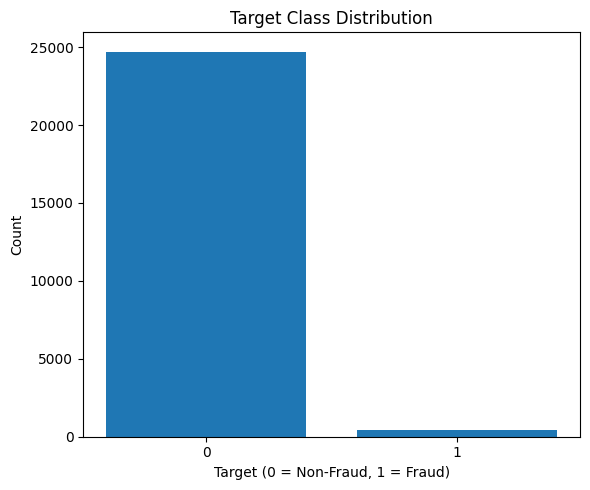

In [102]:

class_distribution = data_capped["TARGET"].value_counts().sort_index()
class_distribution_df = class_distribution.rename_axis("TARGET").reset_index(name="Count")
class_distribution_df["Percentage"] = (class_distribution_df["Count"] / len(data_capped) * 100).round(3)
class_distribution_df.to_csv("tables/class_distribution.csv", index=False)
display(class_distribution_df)

plt.figure(figsize=(6, 5))
plt.bar(class_distribution_df["TARGET"].astype(str), class_distribution_df["Count"])
plt.title("Target Class Distribution")
plt.xlabel("Target (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/target_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


**Class-distribution interpretation**

The target class is **highly imbalanced**, with fraudulent cases forming only a small proportion of the dataset. This means accuracy alone may be misleading during model evaluation, so **recall, precision and F1-score** are more informative when judging whether a model is actually useful for fraud detection.

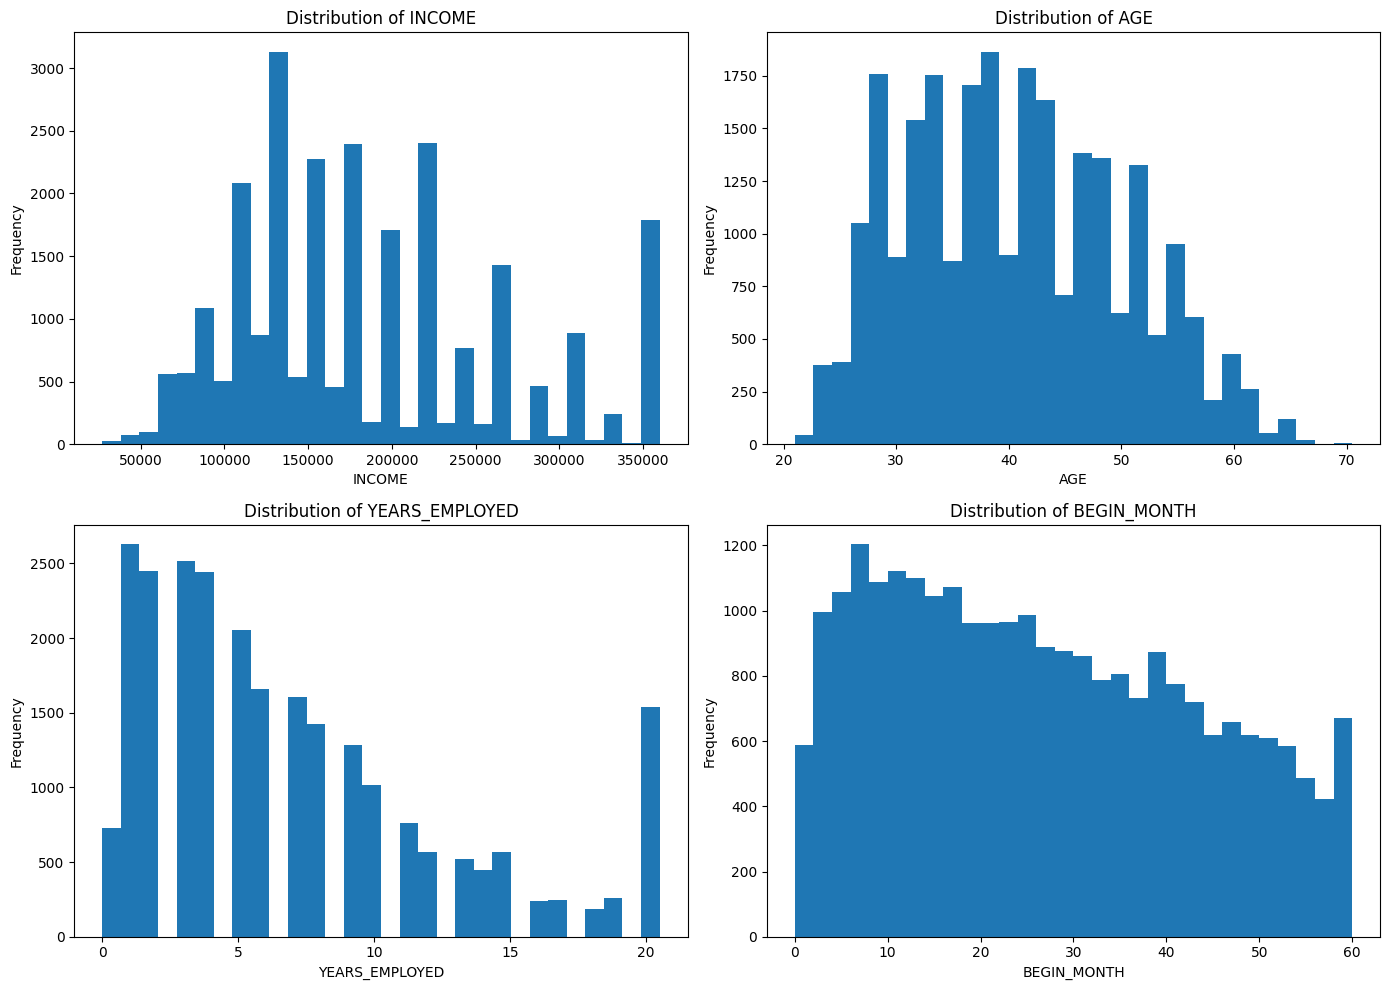

In [103]:

numeric_plot_cols = [col for col in ["INCOME", "AGE", "YEARS_EMPLOYED", "BEGIN_MONTH"] if col in data_capped.columns]

plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_plot_cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(data_capped[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("figures/numerical_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


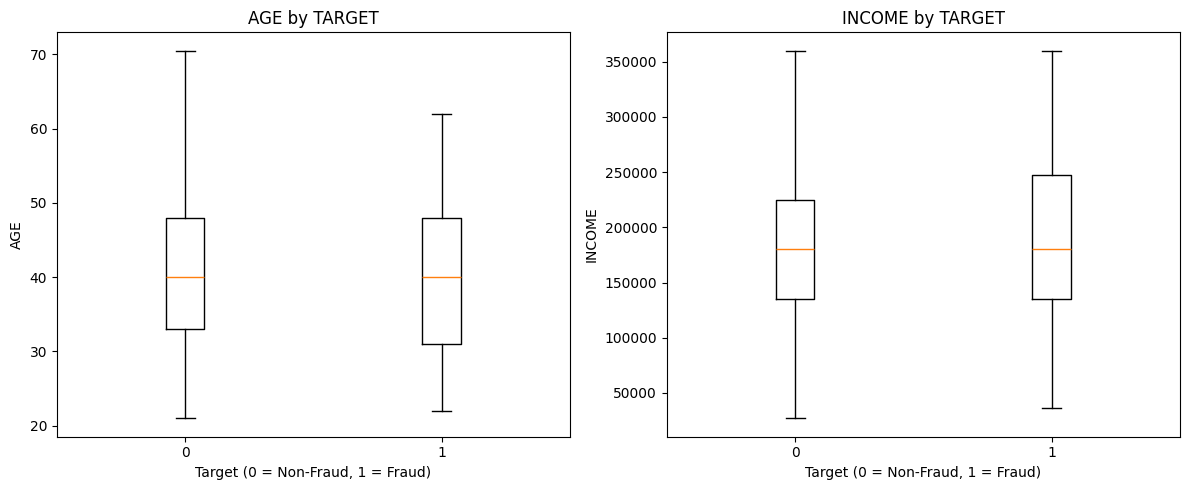

In [104]:
bivariate_numeric_cols = [col for col in ["AGE", "INCOME"] if col in data_capped.columns]

plt.figure(figsize=(12, 5))
for i, col in enumerate(bivariate_numeric_cols, 1):
    plt.subplot(1, len(bivariate_numeric_cols), i)
    nonfraud = data_capped.loc[data_capped["TARGET"] == 0, col].dropna()
    fraud = data_capped.loc[data_capped["TARGET"] == 1, col].dropna()
    plt.boxplot([nonfraud, fraud], labels=["0", "1"])
    plt.title(f"{col} by TARGET")
    plt.xlabel("Target (0 = Non-Fraud, 1 = Fraud)")
    plt.ylabel(col)

plt.tight_layout()
plt.savefig("figures/bivariate_numeric_by_target.png", dpi=300, bbox_inches="tight")
plt.show()

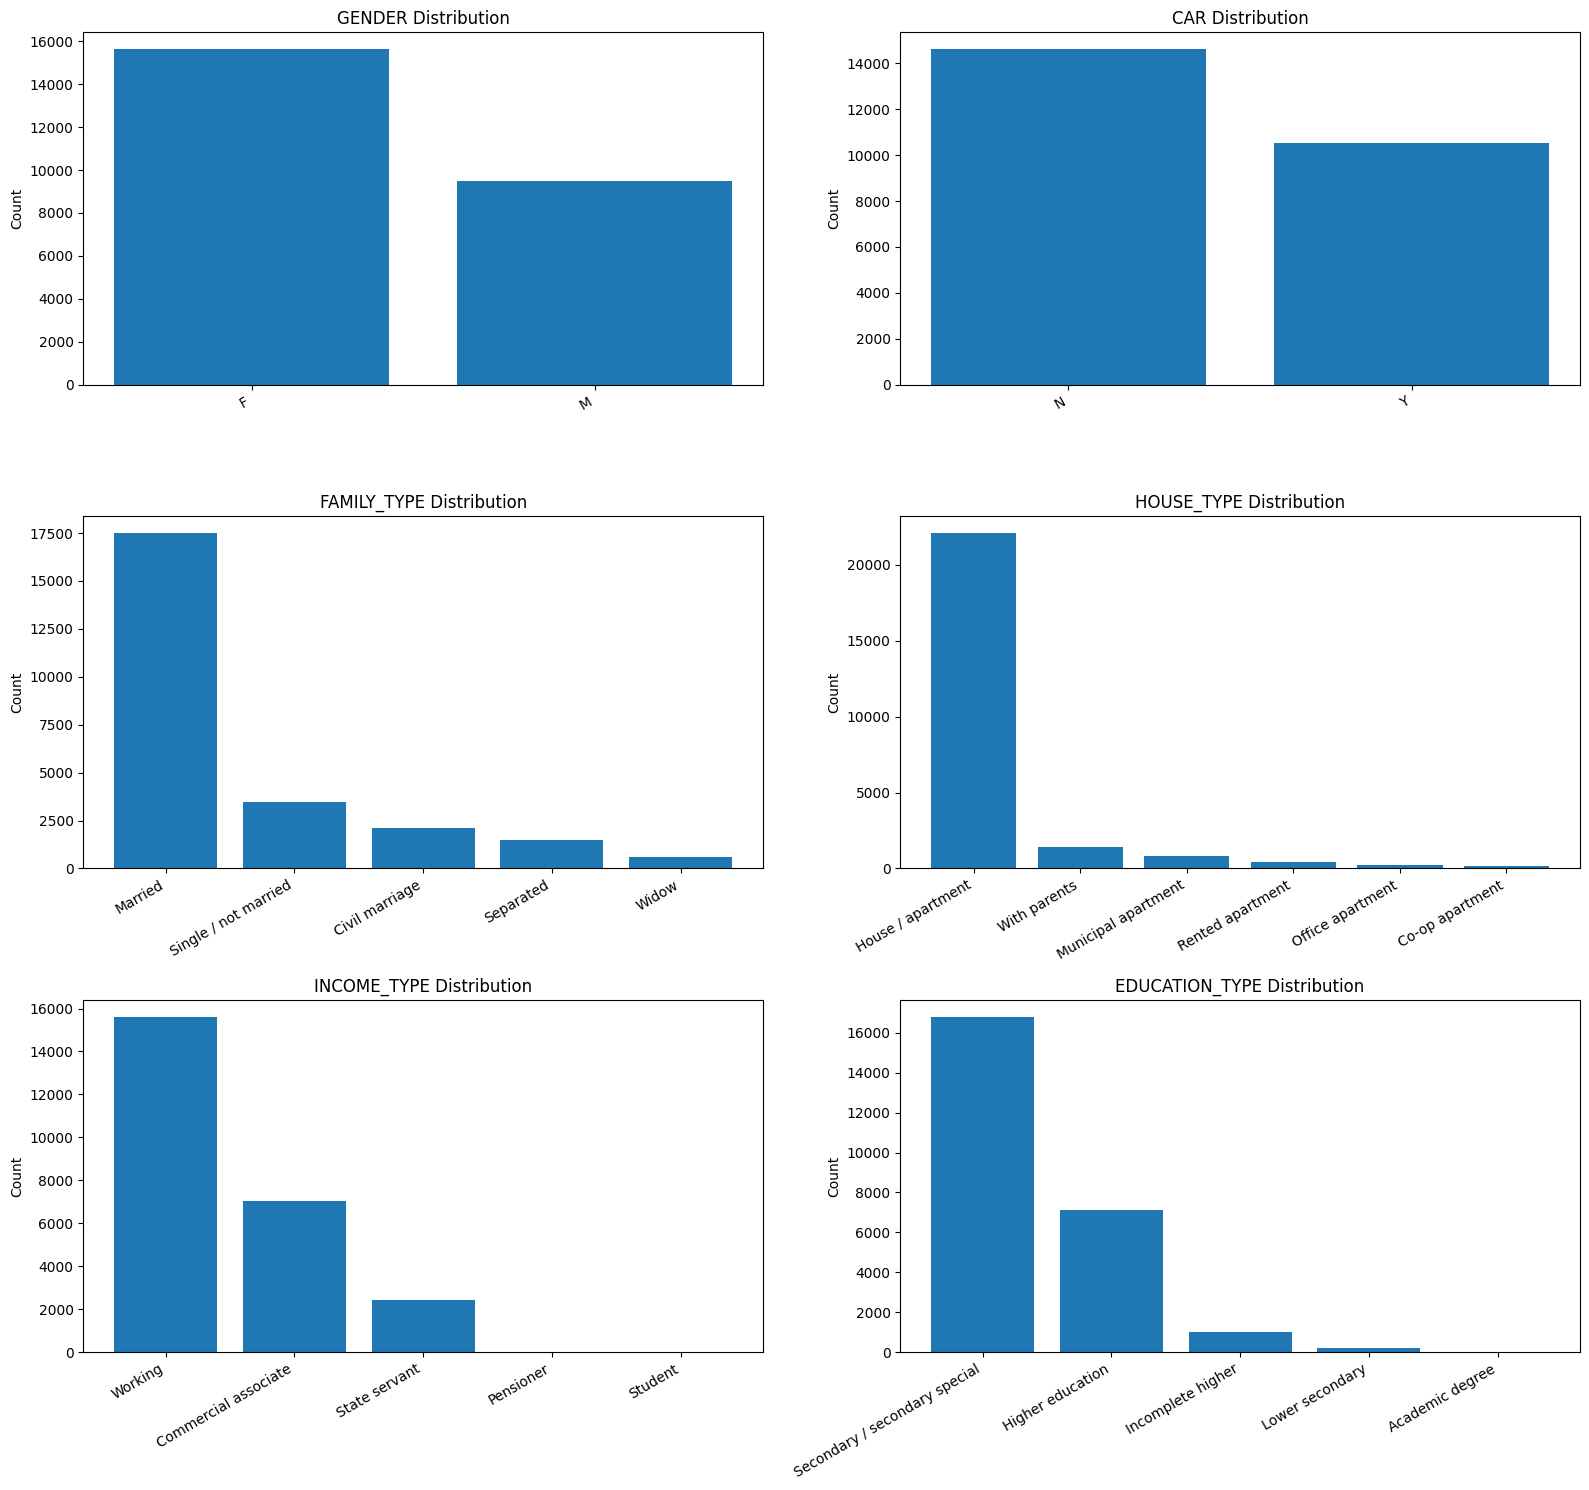

In [105]:

categorical_plot_cols = [col for col in ["GENDER", "CAR", "FAMILY_TYPE", "HOUSE_TYPE", "INCOME_TYPE", "EDUCATION_TYPE"] if col in data_capped.columns]

ncols = 2
nrows = int(np.ceil(len(categorical_plot_cols) / ncols))

plt.figure(figsize=(16, 5 * nrows))
for i, col in enumerate(categorical_plot_cols, 1):
    plt.subplot(nrows, ncols, i)
    counts = data_capped[col].value_counts()
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Count")

plt.tight_layout()
plt.savefig("figures/categorical_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


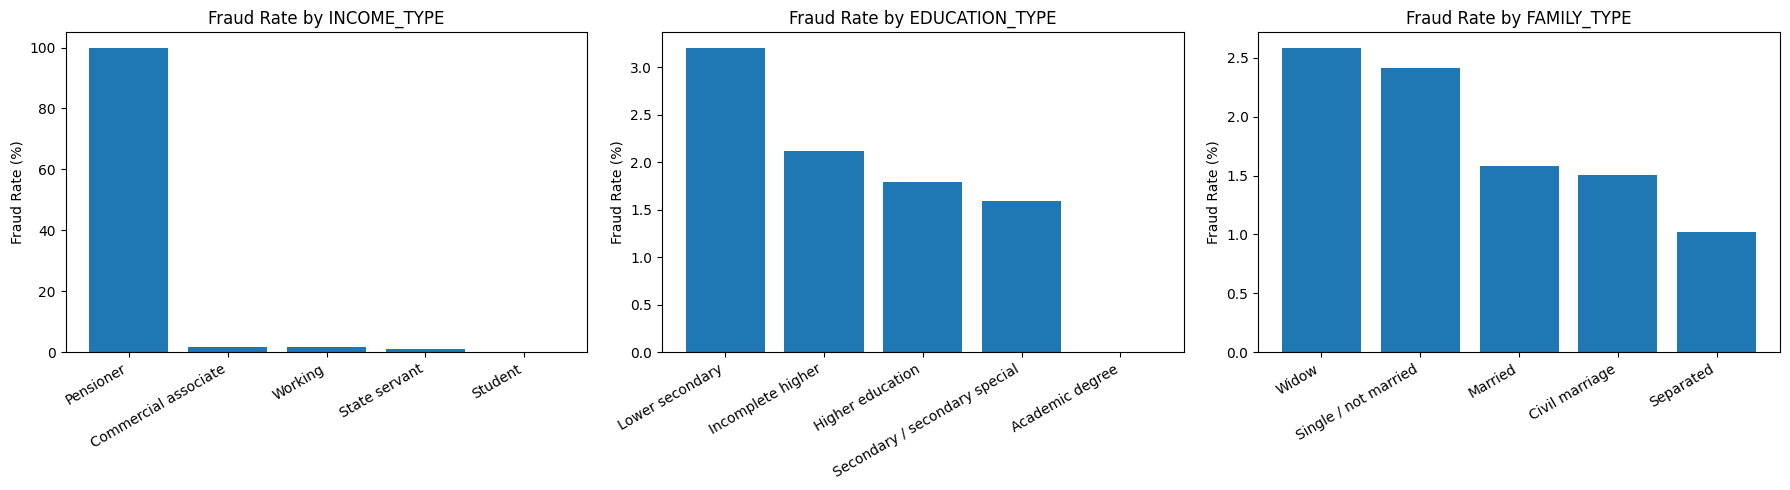

,Variable,Category,Fraud_Rate_Percentage
0,INCOME_TYPE,Pensioner,100.000000
1,INCOME_TYPE,Commercial associate,1.687943
2,INCOME_TYPE,Working,1.670293
3,INCOME_TYPE,State servant,1.190965
4,INCOME_TYPE,Student,0.000000
5,EDUCATION_TYPE,Lower secondary,3.208556
6,EDUCATION_TYPE,Incomplete higher,2.114804
7,EDUCATION_TYPE,Higher education,1.794728
8,EDUCATION_TYPE,Secondary / secondary special,1.588529
9,EDUCATION_TYPE,Academic degree,0.000000


In [106]:
fraud_rate_cols = [col for col in ["INCOME_TYPE", "EDUCATION_TYPE", "FAMILY_TYPE"] if col in data_capped.columns]

fraud_rate_tables = []
plt.figure(figsize=(18, 5))

for i, col in enumerate(fraud_rate_cols, 1):
    rates = (
        data_capped.groupby(col)["TARGET"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .reset_index()
    )
    rates.columns = ["Category", "Fraud_Rate_Percentage"]
    rates["Variable"] = col
    fraud_rate_tables.append(rates[["Variable", "Category", "Fraud_Rate_Percentage"]])

    plt.subplot(1, len(fraud_rate_cols), i)
    plt.bar(rates["Category"].astype(str), rates["Fraud_Rate_Percentage"])
    plt.title(f"Fraud Rate by {col}")
    plt.ylabel("Fraud Rate (%)")
    plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig("figures/fraud_rate_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

fraud_rate_by_category_df = pd.concat(fraud_rate_tables, ignore_index=True)
fraud_rate_by_category_df.to_csv("tables/fraud_rate_by_category.csv", index=False)
display(fraud_rate_by_category_df.head(20))

Some category-level fraud rates may appear extreme where the subgroup size is very small, so these percentages should be interpreted cautiously.

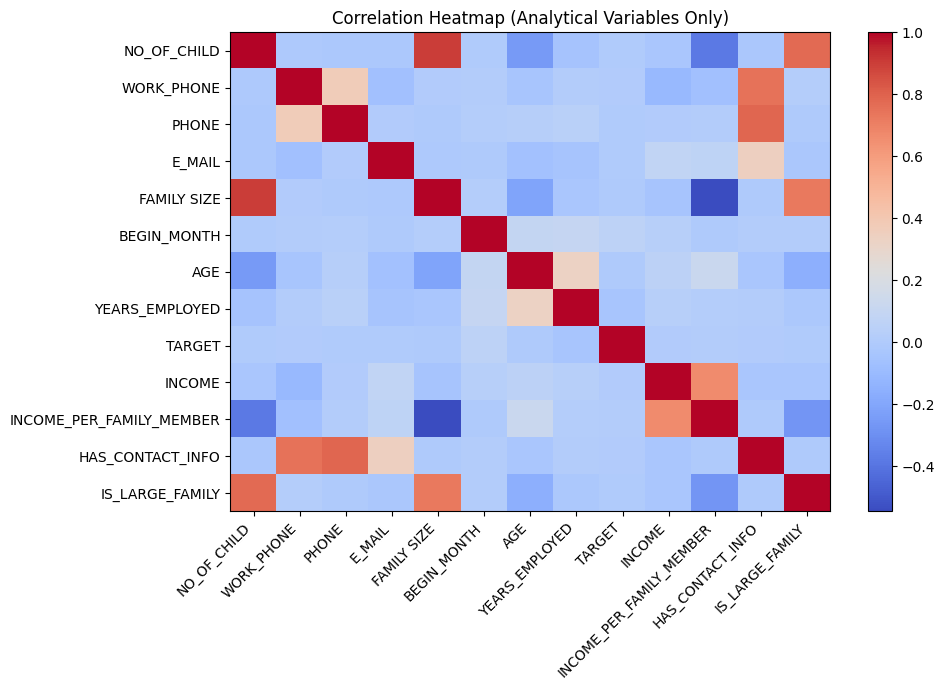

In [107]:
# Correlation analysis should focus only on analytical numeric variables.
# Identifier-like fields and constant columns are excluded.
corr_cols_to_drop = ["ID", "FLAG_MOBIL"]
numeric_data = data_capped.select_dtypes(include=[np.number]).drop(
    columns=[c for c in corr_cols_to_drop if c in data_capped.columns],
    errors="ignore"
)

constant_cols = [col for col in numeric_data.columns if numeric_data[col].nunique() <= 1]
numeric_data = numeric_data.drop(columns=constant_cols, errors="ignore")

correlation_matrix = numeric_data.corr()
correlation_matrix.to_csv("tables/correlation_matrix.csv")

plt.figure(figsize=(10, 7))
plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("Correlation Heatmap (Analytical Variables Only)")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

**EDA interpretation**

- Fraud cases are rare, so the dataset is **heavily imbalanced** and fraud patterns can easily be hidden by the majority non-fraud class.
- Variables such as **income**, **years employed** and the derived household-burden feature show wider spread and some skewness, which supports careful preprocessing and robust model comparison.
- The bivariate charts suggest that fraud behaviour is not evenly distributed across all categories; some **income**, **education** and **family-type** groups show higher fraud rates than others.
- The relationship between **target and age/income** appears to be overlapping rather than cleanly separable, which justifies comparing both a linear model and a non-linear ensemble model.
- Correlations among the numeric variables are generally modest, so the model is likely to benefit from combining multiple weak-to-moderate signals rather than relying on one dominant predictor.
- Because of the severe imbalance, patterns seen in overall distributions do not automatically translate into strong fraud-detection performance; this is why later model evaluation focuses on minority-class metrics rather than accuracy alone.

**EDA / modelling consistency note**

Outlier treatment in Task 2 was applied **for exploratory analysis only**, mainly to improve the readability of boxplots and descriptive summaries.  
For Task 3, the modelling stage used the merged dataset with preprocessing handled inside sklearn pipelines. This approach was chosen to avoid data leakage and to keep imputation, scaling and encoding consistent within the train/validation/test workflow.

## Task 3 – Model building

This section builds two suitable classification models for the fraud detection problem:
1. **Logistic Regression** as an interpretable baseline model
2. **Random Forest** as a stronger non-linear ensemble model

Because the dataset is highly imbalanced, model performance is evaluated using **precision, recall, F1-score, ROC-AUC and Average Precision** instead of accuracy alone.  
The improvement stage includes both **RandomizedSearchCV hyperparameter optimisation** for Random Forest and **threshold tuning on a validation set**, so the final model choice reflects both model quality and decision-threshold quality.

In [108]:
# ------------------------------------------------------------
# 1. Prepare modelling dataset
# ------------------------------------------------------------
# Use the merged dataset with engineered features added in a controlled way.
# Missing values will still be handled safely inside the preprocessing pipelines.

model_data = add_engineered_features(data.copy())

drop_cols = ["TARGET", "ID", "FLAG_MOBIL"]
X = model_data.drop(columns=drop_cols, errors="ignore")
y = model_data["TARGET"].astype(int)

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
engineered_features_in_model = [col for col in ["INCOME_PER_FAMILY_MEMBER", "HAS_CONTACT_INFO", "IS_LARGE_FAMILY"] if col in X.columns]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Engineered features included:", engineered_features_in_model)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

pd.DataFrame({"Feature": X.columns, "Data_Type": X.dtypes.astype(str).values}).to_csv(
    "tables/task3_feature_list.csv", index=False
)
X.head().to_csv("tables/task3_model_feature_preview.csv", index=False)

Numeric features: ['NO_OF_CHILD', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'INCOME', 'INCOME_PER_FAMILY_MEMBER', 'HAS_CONTACT_INFO', 'IS_LARGE_FAMILY']
Categorical features: ['GENDER', 'CAR', 'REALITY', 'FAMILY_TYPE', 'HOUSE_TYPE', 'INCOME_TYPE', 'EDUCATION_TYPE']
Engineered features included: ['INCOME_PER_FAMILY_MEMBER', 'HAS_CONTACT_INFO', 'IS_LARGE_FAMILY']
Feature matrix shape: (25134, 19)
Target shape: (25134,)


In [109]:
# ------------------------------------------------------------
# 2. Train / validation / test split
# ------------------------------------------------------------
# 60% train, 20% validation, 20% test

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

split_summary = pd.DataFrame({
    "Split": ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test"],
    "Shape": [
        str(X_train.shape), str(X_val.shape), str(X_test.shape),
        str(y_train.shape), str(y_val.shape), str(y_test.shape)
    ]
})
display(split_summary)
split_summary.to_csv("tables/task3_split_summary.csv", index=False)

,Split,Shape
0,X_train,"(15080, 19)"
1,X_val,"(5027, 19)"
2,X_test,"(5027, 19)"
3,y_train,"(15080,)"
4,y_val,"(5027,)"
5,y_test,"(5027,)"


In [110]:
# ------------------------------------------------------------
# 3. Build preprocessing pipelines and models
# ------------------------------------------------------------
lr_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

lr_model = Pipeline([
    ("preprocessor", lr_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

rf_model = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

print("Logistic Regression and Random Forest pipelines are ready.")

Logistic Regression and Random Forest pipelines are ready.


In [112]:
# ------------------------------------------------------------
# 4. Helper functions
# ------------------------------------------------------------
def evaluate_with_threshold(y_true, y_prob, threshold=0.50):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1_Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "Average_Precision": average_precision_score(y_true, y_prob),
        "Threshold": threshold
    }

def find_best_threshold(y_true, y_prob):
    best_threshold = 0.50
    best_f1 = -1

    for threshold in np.linspace(0.01, 0.99, 99):
        y_pred = (y_prob >= threshold).astype(int)
        score = f1_score(y_true, y_pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_threshold = float(threshold)

    return best_threshold, best_f1

def save_confusion_matrix(cm, title, filename):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.xticks([0, 1], ["Pred_0", "Pred_1"])
    plt.yticks([0, 1], ["Actual_0", "Actual_1"])
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

In [113]:
# ------------------------------------------------------------
# 5. Train models, optimise Random Forest, and tune thresholds on validation set
# ------------------------------------------------------------
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

rf_param_distributions = {
    "classifier__n_estimators": [200, 300, 400, 500],
    "classifier__max_depth": [None, 10, 15, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__class_weight": ["balanced", "balanced_subsample"]
}

rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_param_distributions,
    n_iter=12,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
rf_random_search.fit(X_train, y_train)

rf_tuned_model = rf_random_search.best_estimator_
rf_tuned_best_params = rf_random_search.best_params_

lr_val_prob = lr_model.predict_proba(X_val)[:, 1]
lr_test_prob = lr_model.predict_proba(X_test)[:, 1]

rf_val_prob = rf_model.predict_proba(X_val)[:, 1]
rf_test_prob = rf_model.predict_proba(X_test)[:, 1]

rf_tuned_val_prob = rf_tuned_model.predict_proba(X_val)[:, 1]
rf_tuned_test_prob = rf_tuned_model.predict_proba(X_test)[:, 1]

lr_best_threshold, lr_val_best_f1 = find_best_threshold(y_val, lr_val_prob)
rf_best_threshold, rf_val_best_f1 = find_best_threshold(y_val, rf_val_prob)
rf_tuned_best_threshold, rf_tuned_val_best_f1 = find_best_threshold(y_val, rf_tuned_val_prob)

threshold_summary = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Random Forest (RandomizedSearchCV)"],
    "Best_Validation_Threshold": [lr_best_threshold, rf_best_threshold, rf_tuned_best_threshold],
    "Best_Validation_F1": [lr_val_best_f1, rf_val_best_f1, rf_tuned_val_best_f1]
})

rf_random_search_results = pd.DataFrame(rf_random_search.cv_results_).sort_values(
    by="rank_test_score"
)[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_classifier__n_estimators",
    "param_classifier__max_depth",
    "param_classifier__min_samples_split",
    "param_classifier__min_samples_leaf",
    "param_classifier__class_weight"
]]

rf_best_params_df = pd.DataFrame({
    "Parameter": list(rf_tuned_best_params.keys()),
    "Best_Value": list(rf_tuned_best_params.values())
})

display(threshold_summary)
display(rf_best_params_df)

threshold_summary.to_csv("tables/task3_threshold_tuning_summary.csv", index=False)
rf_best_params_df.to_csv("tables/random_forest_randomized_search_best_params.csv", index=False)
rf_random_search_results.to_csv("tables/random_forest_randomized_search_results.csv", index=False)

with open("logs/random_forest_randomized_search_log.txt", "w") as f:
    f.write("Random Forest RandomizedSearchCV Best Parameters\n")
    f.write("=" * 60 + "\n")
    for param, value in rf_tuned_best_params.items():
        f.write(f"{param}: {value}\n")
    f.write("\nBest cross-validated F1 score: ")
    f.write(str(rf_random_search.best_score_))

,Model,Best_Validation_Threshold,Best_Validation_F1
0,Logistic Regression,0.76,0.080645
1,Random Forest,0.12,0.344444
2,Random Forest (RandomizedSearchCV),0.43,0.293333


,Parameter,Best_Value
0,classifier__n_estimators,300
1,classifier__min_samples_split,5
2,classifier__min_samples_leaf,1
3,classifier__max_depth,15
4,classifier__class_weight,balanced


In [115]:
# ------------------------------------------------------------
# 6. Final comparison table
# ------------------------------------------------------------
results = []

results.append({
    "Model": "Logistic Regression",
    "Version": "Default threshold (0.50)",
    **evaluate_with_threshold(y_test, lr_test_prob, 0.50)
})

results.append({
    "Model": "Logistic Regression",
    "Version": f"Threshold tuned on validation ({lr_best_threshold:.2f})",
    **evaluate_with_threshold(y_test, lr_test_prob, lr_best_threshold)
})

results.append({
    "Model": "Random Forest",
    "Version": "Default threshold (0.50)",
    **evaluate_with_threshold(y_test, rf_test_prob, 0.50)
})

results.append({
    "Model": "Random Forest",
    "Version": f"Threshold tuned on validation ({rf_best_threshold:.2f})",
    **evaluate_with_threshold(y_test, rf_test_prob, rf_best_threshold)
})

results.append({
    "Model": "Random Forest (RandomizedSearchCV)",
    "Version": "Default threshold (0.50)",
    **evaluate_with_threshold(y_test, rf_tuned_test_prob, 0.50)
})

results.append({
    "Model": "Random Forest (RandomizedSearchCV)",
    "Version": f"Threshold tuned on validation ({rf_tuned_best_threshold:.2f})",
    **evaluate_with_threshold(y_test, rf_tuned_test_prob, rf_tuned_best_threshold)
})

final_results = pd.DataFrame(results).sort_values(by=["F1_Score", "Recall", "ROC_AUC"], ascending=False)
display(final_results)

final_results.to_csv("tables/final_model_comparison.csv", index=False)

,Model,Version,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Average_Precision,Threshold
3,Random Forest,Threshold tuned on validation (0.12),0.976129,0.308511,0.345238,0.325843,0.773008,0.198068,0.12
5,Random Forest (RandomizedSearchCV),Threshold tuned on validation (0.43),0.980107,0.366667,0.261905,0.305556,0.780965,0.187064,0.43
4,Random Forest (RandomizedSearchCV),Default threshold (0.50),0.982296,0.435897,0.202381,0.276423,0.780965,0.187064,0.50
2,Random Forest,Default threshold (0.50),0.981699,0.346154,0.107143,0.163636,0.773008,0.198068,0.50
1,Logistic Regression,Threshold tuned on validation (0.76),0.960215,0.097222,0.166667,0.122807,0.668636,0.091635,0.76
0,Logistic Regression,Default threshold (0.50),0.654466,0.029060,0.607143,0.055465,0.668636,0.091635,0.50


**Model comparison interpretation**

The additional RandomizedSearchCV step improved the rigour of the modelling process by testing multiple Random Forest hyperparameter combinations instead of relying only on default settings. However, the final comparison showed that the simpler Random Forest model with validation-based threshold tuning still achieved the highest F1-score on the test set. This indicates that additional optimisation does not always guarantee the best final minority-class result.

A conflicting observation was found between accuracy and fraud-detection quality. Because the dataset is highly imbalanced, a model can achieve high accuracy by predicting most records as non-fraud, while still performing poorly on the fraud class. For this reason, recall, precision, F1-score, ROC-AUC and Average Precision were treated as more meaningful than accuracy when selecting the final model.

The final selected model was the threshold-tuned Random Forest, because it achieved the best balance between identifying fraud and limiting false alarms among the evaluated alternatives.

In [116]:
# ------------------------------------------------------------
# 7. Cross-validation summary
# ------------------------------------------------------------
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lr_cv_f1 = cross_val_score(
    lr_model, X_train_full, y_train_full, cv=cv_strategy, scoring="f1", n_jobs=-1
)

rf_cv_f1 = cross_val_score(
    rf_model, X_train_full, y_train_full, cv=cv_strategy, scoring="f1", n_jobs=-1
)

rf_tuned_cv_f1 = cross_val_score(
    rf_tuned_model, X_train_full, y_train_full, cv=cv_strategy, scoring="f1", n_jobs=-1
)

cv_results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Random Forest (RandomizedSearchCV)"],
    "CV_F1_Mean": [lr_cv_f1.mean(), rf_cv_f1.mean(), rf_tuned_cv_f1.mean()],
    "CV_F1_STD": [lr_cv_f1.std(), rf_cv_f1.std(), rf_tuned_cv_f1.std()]
})

display(cv_results_df)
cv_results_df.to_csv("tables/cross_validation_results.csv", index=False)

,Model,CV_F1_Mean,CV_F1_STD
0,Logistic Regression,0.051161,0.003604
1,Random Forest,0.145512,0.023713
2,Random Forest (RandomizedSearchCV),0.200491,0.012374


**Cross-validation note**

The cross-validation scores were used to assess how stable each model was across different training folds.  
The additional RandomizedSearchCV step was performed **only on the training split**, which keeps model optimisation separate from the validation-based threshold tuning and the final test evaluation.  
This separation is important because cross-validation reflects model stability, hyperparameter search reflects model optimisation, and threshold tuning reflects practical decision-making on an imbalanced dataset.

In [117]:
# ------------------------------------------------------------
# 8. Select the best final model
# ------------------------------------------------------------
best_row = final_results.iloc[0]
best_model_name = best_row["Model"]
best_version = best_row["Version"]

rf_tuned_classifier_params = {
    key.replace("classifier__", ""): value
    for key, value in rf_tuned_best_params.items()
    if key.startswith("classifier__")
}

if best_model_name == "Logistic Regression":
    selected_threshold = lr_best_threshold if "Threshold tuned" in best_version else 0.50
    selected_test_prob = lr_test_prob

    final_deployment_model = Pipeline([
        ("preprocessor", lr_preprocessor),
        ("classifier", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42
        ))
    ])

elif best_model_name == "Random Forest":
    selected_threshold = rf_best_threshold if "Threshold tuned" in best_version else 0.50
    selected_test_prob = rf_test_prob

    final_deployment_model = Pipeline([
        ("preprocessor", rf_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ])

else:
    selected_threshold = rf_tuned_best_threshold if "Threshold tuned" in best_version else 0.50
    selected_test_prob = rf_tuned_test_prob

    final_deployment_model = Pipeline([
        ("preprocessor", rf_preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            **rf_tuned_classifier_params
        ))
    ])

best_test_prob = selected_test_prob
best_test_pred = (best_test_prob >= selected_threshold).astype(int)

best_model_summary = pd.DataFrame({
    "Selected_Final_Model": [best_model_name],
    "Selected_Version": [best_version],
    "Selected_Threshold": [selected_threshold]
})
display(best_model_summary)

# Retrain the final deployment model on the full development set
# (train + validation) after model selection.
final_deployment_model.fit(X_train_full, y_train_full)

joblib.dump(final_deployment_model, "models/final_selected_model_pipeline.pkl")
joblib.dump(selected_threshold, "models/final_selected_threshold.pkl")

with open("logs/final_selected_model_classification_report.txt", "w") as f:
    f.write(classification_report(y_test, best_test_pred, zero_division=0))

,Selected_Final_Model,Selected_Version,Selected_Threshold
0,Random Forest,Threshold tuned on validation (0.12),0.12


In [118]:
if best_model_name == "Random Forest":
    joblib.dump(final_deployment_model, "models/random_forest_balanced_pipeline.pkl")
    joblib.dump(selected_threshold, "models/random_forest_best_threshold.pkl")

In [119]:
final_lr_deployment_model = Pipeline([
    ("preprocessor", lr_preprocessor),
    ("classifier", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

final_lr_deployment_model.fit(X_train_full, y_train_full)

joblib.dump(final_lr_deployment_model, "models/logistic_regression_pipeline.pkl")
joblib.dump(lr_best_threshold, "models/logistic_regression_best_threshold.pkl")
print("Logistic Regression deployment files saved.")

Logistic Regression deployment files saved.


In [129]:
# Save the RandomizedSearchCV-tuned Random Forest model for GUI use
final_rf_random_search_model = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        **rf_tuned_classifier_params
    ))
])

final_rf_random_search_model.fit(X_train_full, y_train_full)

joblib.dump(final_rf_random_search_model, "models/random_forest_randomized_search_pipeline.pkl")
joblib.dump(rf_tuned_best_threshold, "models/random_forest_randomized_search_best_threshold.pkl")

print("Random Forest (RandomizedSearchCV) deployment files saved.")

Random Forest (RandomizedSearchCV) deployment files saved.


,Pred_0,Pred_1
Actual_0,4878,65
Actual_1,55,29


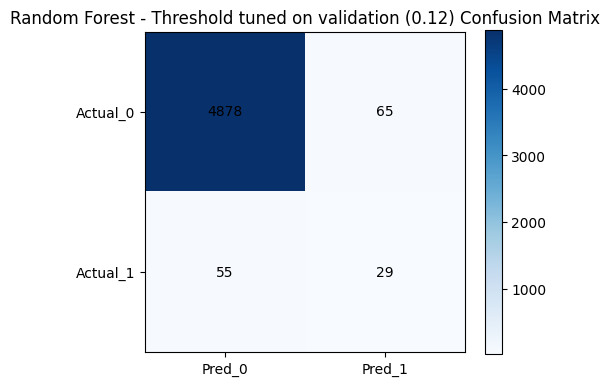

In [120]:
# ------------------------------------------------------------
# 9. Confusion matrix of the final model
# ------------------------------------------------------------
best_cm = confusion_matrix(y_test, best_test_pred)
best_cm_df = pd.DataFrame(best_cm, index=["Actual_0", "Actual_1"], columns=["Pred_0", "Pred_1"])
display(best_cm_df)

best_cm_df.to_csv("tables/final_selected_model_confusion_matrix.csv")

save_confusion_matrix(
    best_cm,
    f"{best_model_name} - {best_version} Confusion Matrix",
    "figures/final_selected_model_confusion_matrix.png"
)

**Confusion matrix interpretation**

The confusion matrix makes the fraud-detection trade-off easier to interpret than accuracy alone. A stronger fraud model should identify more true fraud cases, but this usually comes with some increase in false positives. In this notebook, the final selected model was chosen because it improves the balance between **capturing fraud** and **keeping false alarms at a manageable level**, which is more appropriate for fraud screening than maximising overall accuracy only.

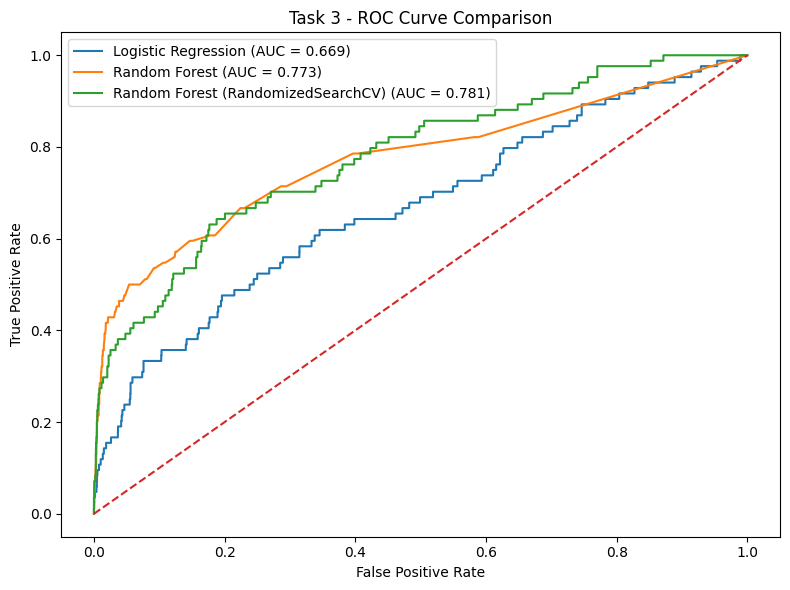

In [121]:
# ------------------------------------------------------------
# 10. ROC curve comparison
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
for name, probs in {
    "Logistic Regression": lr_test_prob,
    "Random Forest": rf_test_prob,
    "Random Forest (RandomizedSearchCV)": rf_tuned_test_prob
}.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {score:.3f})")

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Task 3 - ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("figures/roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

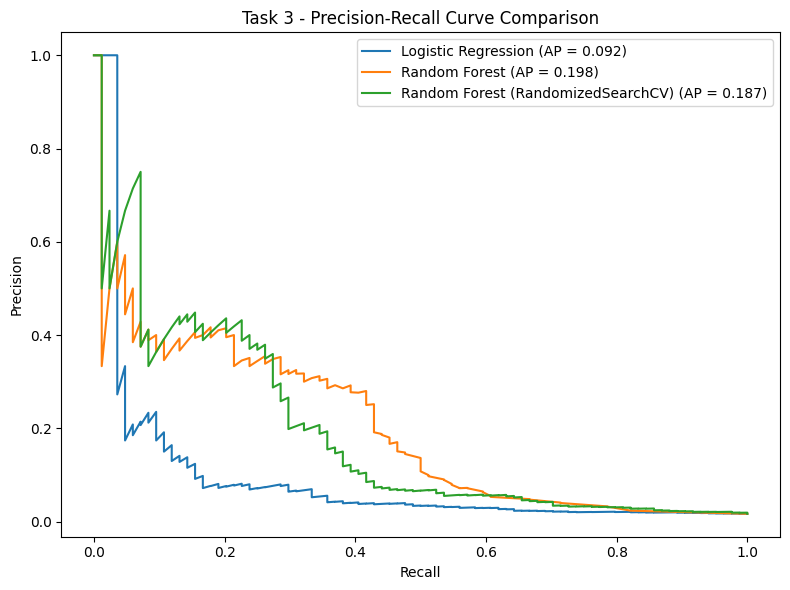

In [122]:
# ------------------------------------------------------------
# 11. Precision-Recall curve comparison
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
for name, probs in {
    "Logistic Regression": lr_test_prob,
    "Random Forest": rf_test_prob,
    "Random Forest (RandomizedSearchCV)": rf_tuned_test_prob
}.items():
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, probs)
    ap_score = average_precision_score(y_test, probs)
    plt.plot(recall_vals, precision_vals, label=f"{name} (AP = {ap_score:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Task 3 - Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("figures/precision_recall_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

,Feature,Importance
5,num__BEGIN_MONTH,0.174768
6,num__AGE,0.122048
7,num__YEARS_EMPLOYED,0.110758
9,num__INCOME_PER_FAMILY_MEMBER,0.104412
8,num__INCOME,0.093072
4,num__FAMILY SIZE,0.030308
10,num__HAS_CONTACT_INFO,0.029866
0,num__NO_OF_CHILD,0.024422
2,num__PHONE,0.017772
33,cat__INCOME_TYPE_Working,0.017357


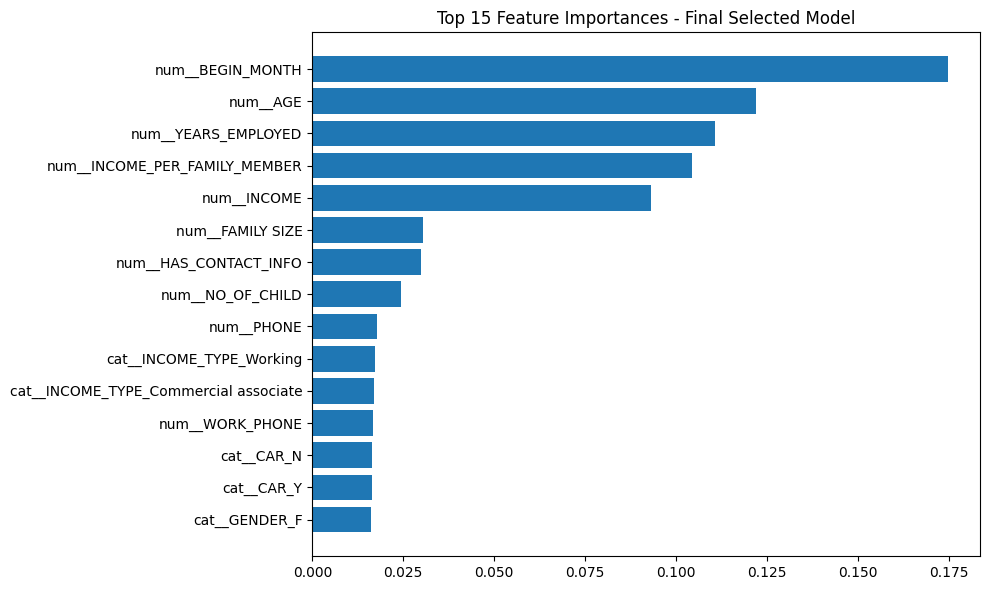

In [123]:
# ------------------------------------------------------------
# 12. Feature importance / coefficient interpretation of the final model
# ------------------------------------------------------------
final_preprocessor = final_deployment_model.named_steps["preprocessor"]
final_classifier = final_deployment_model.named_steps["classifier"]
final_feature_names = final_preprocessor.get_feature_names_out()

if hasattr(final_classifier, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "Feature": final_feature_names,
        "Importance": final_classifier.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    top_features = feature_importance.head(15)
    display(top_features)
    feature_importance.to_csv("tables/final_model_feature_importance.csv", index=False)

    plt.figure(figsize=(10, 6))
    plt.barh(top_features["Feature"], top_features["Importance"])
    plt.gca().invert_yaxis()
    plt.title("Top 15 Feature Importances - Final Selected Model")
    plt.tight_layout()
    plt.savefig("figures/top15_feature_importance_final_model.png", dpi=300, bbox_inches="tight")
    plt.show()

else:
    coefficient_values = np.ravel(final_classifier.coef_)
    feature_importance = pd.DataFrame({
        "Feature": final_feature_names,
        "Coefficient": coefficient_values,
        "Absolute_Coefficient": np.abs(coefficient_values)
    }).sort_values(by="Absolute_Coefficient", ascending=False)

    top_features = feature_importance.head(15)
    display(top_features)
    feature_importance.to_csv("tables/final_model_coefficients.csv", index=False)

    plt.figure(figsize=(10, 6))
    plt.barh(top_features["Feature"], top_features["Absolute_Coefficient"])
    plt.gca().invert_yaxis()
    plt.title("Top 15 Absolute Coefficients - Final Selected Model")
    plt.tight_layout()
    plt.savefig("figures/top15_coefficients_final_model.png", dpi=300, bbox_inches="tight")
    plt.show()

In [125]:
# ------------------------------------------------------------
# 13. Interpretation of Task 3 results
# ------------------------------------------------------------
best_row = final_results.iloc[0]

print("Task 3 Interpretation")
print("-" * 60)
print("The final selected model is:", best_row["Model"])
print("Version:", best_row["Version"])
print(f"Accuracy: {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall: {best_row['Recall']:.4f}")
print(f"F1-Score: {best_row['F1_Score']:.4f}")
print(f"ROC-AUC: {best_row['ROC_AUC']:.4f}")
print(f"Average Precision: {best_row['Average_Precision']:.4f}")
print()
print("Interpretation:")
print("The dataset is highly imbalanced, so accuracy alone would be misleading.")
print("RandomizedSearchCV improved the rigour of the modelling process by testing")
print("multiple Random Forest hyperparameter combinations.")
print("However, the simpler Random Forest with validation-based threshold tuning")
print("still achieved the highest F1-score on the test set.")
print("This shows that additional optimisation does not always produce the best")
print("final minority-class result.")
print("The final selected model was chosen because it gave the best balance")
print("between fraud detection and false-positive control.")

Task 3 Interpretation
------------------------------------------------------------
The final selected model is: Random Forest
Version: Threshold tuned on validation (0.12)
Accuracy: 0.9761
Precision: 0.3085
Recall: 0.3452
F1-Score: 0.3258
ROC-AUC: 0.7730
Average Precision: 0.1981

Interpretation:
The dataset is highly imbalanced, so accuracy alone would be misleading.
RandomizedSearchCV improved the rigour of the modelling process by testing
multiple Random Forest hyperparameter combinations.
However, the simpler Random Forest with validation-based threshold tuning
still achieved the highest F1-score on the test set.
This shows that additional optimisation does not always produce the best
final minority-class result.
The final selected model was chosen because it gave the best balance
between fraud detection and false-positive control.


In [126]:
completion_checklist = pd.DataFrame([
    ["Task 1 - Dataset import", "Done"],
    ["Task 1 - Dataset merge", "Done"],
    ["Task 1 - Merge validation and analytical dataset cleanup", "Done"],
    ["Task 2A - Shape, columns, data types", "Done"],
    ["Task 2A - Missing value analysis", "Done"],
    ["Task 2A - Unique value summary", "Done"],
    ["Task 2A - Summary table with key dataset metrics", "Done"],
    ["Task 2B - Missing value treatment", "Done"],
    ["Task 2B - Duplicate analysis", "Done"],
    ["Task 2B - Outlier analysis", "Done"],
    ["Task 2B - Outlier capping", "Done"],
    ["Task 2B - Feature engineering", "Done"],
    ["Task 2B - Encoding / feature preparation", "Done"],
    ["Task 2C - Descriptive statistics", "Done"],
    ["Task 2C - Numerical visualisations", "Done"],
    ["Task 2C - Bivariate target-based visualisations", "Done"],
    ["Task 2C - Fraud-rate-by-category analysis", "Done"],
    ["Task 2C - Correlation heatmap", "Done"],
    ["Task 3 - Logistic Regression baseline", "Done"],
    ["Task 3 - Random Forest model", "Done"],
    ["Task 3 - Metrics comparison", "Done"],
    ["Task 3 - Model improvement using RandomizedSearchCV + threshold tuning", "Done"],
    ["Task 3 - Cross-validation", "Done"],
    ["Task 3 - Final confusion matrix and ROC/PR curves", "Done"],
    ["Task 4 - GUI", "Developed separately (see GUI files/screenshots)"],
    ["Task 5 - GitHub screenshot evidence", "Added manually"]
], columns=["Requirement", "Status"])

completion_checklist.to_csv("tables/completion_checklist.csv", index=False)
display(completion_checklist)

,Requirement,Status
0,Task 1 - Dataset import,Done
1,Task 1 - Dataset merge,Done
2,Task 1 - Merge validation and analytical datas...,Done
3,"Task 2A - Shape, columns, data types",Done
4,Task 2A - Missing value analysis,Done
5,Task 2A - Unique value summary,Done
6,Task 2A - Summary table with key dataset metrics,Done
7,Task 2B - Missing value treatment,Done
8,Task 2B - Duplicate analysis,Done
9,Task 2B - Outlier analysis,Done


In [127]:
with open("reports/final_summary_report.txt", "w") as f:
    f.write("Fraud Detection Analysis Summary\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Analytical dataset shape: {data.shape}\n")
    f.write(f"Feature matrix shape: {X.shape}\n")
    f.write(f"Engineered features: {engineered_features_in_model}\n\n")
    f.write("Note: Outlier capping was used for EDA only; the modelling stage used pipeline-based preprocessing.\n\n")
    f.write("Class distribution:\n")
    f.write(class_distribution_df.to_string(index=False))
    f.write("\n\nRandomizedSearchCV best parameters:\n")
    f.write(rf_best_params_df.to_string(index=False))
    f.write("\n\nFinal model comparison:\n")
    f.write(final_results.to_string(index=False))
    f.write("\n\nCross-validation results:\n")
    f.write(cv_results_df.to_string(index=False))
    f.write("\n\nSelected final model:\n")
    f.write(best_model_summary.to_string(index=False))
    f.write("\n\nTop feature summary:\n")
    f.write(top_features.to_string(index=False))

print("Summary report saved successfully.")

Summary report saved successfully.


In [128]:
print("Notebook executed successfully from top to bottom.")
print("Saved outputs in figures/, tables/, logs/, models/, and reports/.")


Notebook executed successfully from top to bottom.
Saved outputs in figures/, tables/, logs/, models/, and reports/.
